# Workshop 03 — Your First MMM

You now know what a posterior is ([workshop 00](workshop_00_thinking_in_distributions.ipynb)),
where priors come from ([workshop 01](workshop_01_priors.ipynb)), and how a
sampler finds the posterior and how to check that it did
([workshop 02](workshop_02_sampling.ipynb)). Time to point all that machinery at
the actual question your stakeholders care about: **which marketing channels
drive sales, and by how much?**

That question has a name — **Marketing Mix Modeling (MMM)**: a statistical model
that reads a brand's weekly history of spend and sales and estimates how much
each channel contributed. In this notebook you will fit your first one, end to
end: meet the data, understand the two transformations that make media special
(**adstock** and **saturation**), configure and fit a `BayesianMMM`, pass the
diagnostics gate from workshop 02, and read the answer.

And here is the series' honesty device, stated up front: **we practice on a
synthetic world where the true answer is known.** The data below was *generated*
by code in this repo (`tests/synth/dgp.py`), so we hold the answer key — the
true contribution of every channel, to the decimal. Real marketing data never
comes with an answer key, which is exactly why we train on data that does: it is
the only way to *grade ourselves* instead of merely admiring a converged model.
At the end of this notebook we will put the model's estimates next to the truth
and measure the gap.

> One fit, about a minute of sampling. Everything else is reading, looking at
> data, and playing with sliders.

In [1]:
import sys, pathlib, warnings, logging, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
# pymc emits sampler warnings at ERROR level -> CRITICAL to keep outputs clean
for _n in ("pymc", "numpyro", "jax", "arviz", "pytensor"):
    logging.getLogger(_n).setLevel(logging.CRITICAL)
try:  # the validation suite logs via loguru, which bypasses stdlib logging
    from loguru import logger as _loguru
    _loguru.disable("mmm_framework")
except ImportError:
    pass
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from tests.synth import dgp  # the synthetic-world factory (with answer keys)

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "notebook_connected"
PLOTLY_LAYOUT = dict(template="plotly_white", font=dict(size=12))

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")
PAL = {"TV": ACCENT, "Search": SKY, "Social": BERRY, "Display": LEAF}

assert pio.renderers.default == "notebook_connected"
assert len(PAL) == 4
print("setup ok — synthetic worlds available:", len(dgp.SCENARIOS))

setup ok — synthetic worlds available: 22


## 1 — MMM in one picture

Every MMM tells the same generative story about a week of sales, and the whole
vocabulary of the field is just names for the boxes in that story. Read the
diagram below left to right:

1. You spend money on a channel this week.
2. Part of the effect lands this week and part **carries over** into the next
   few weeks — that memory is **adstock**.
3. Doubling spend does not double the effect — the response bends and flattens.
   That bending is **saturation** (diminishing returns).
4. The bent, carried-over signal gets multiplied by an **effect size** β — how
   strongly this channel moves the KPI at all.
5. Sum across channels, add the **baseline** — everything that would have
   happened with zero marketing — and you have the week's expected KPI.

Each box has parameters the model does not know — and *every one of them gets a
prior and a posterior*. That is the entire trick: an MMM is the Bayesian
workflow from workshops 00–02 applied to this one diagram.

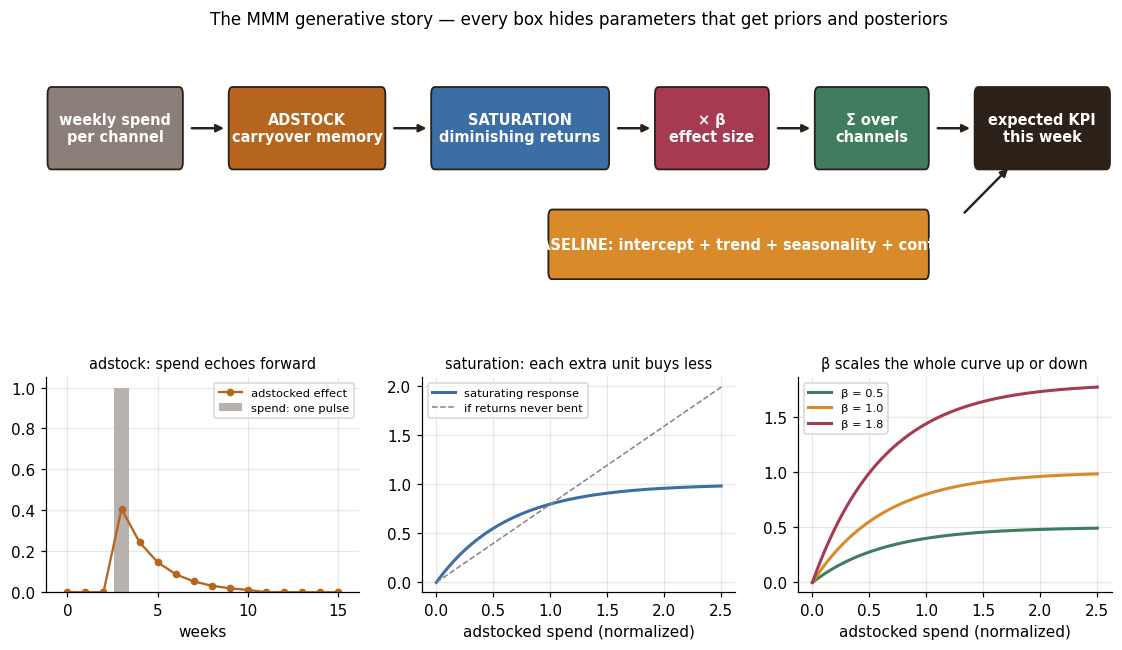

✓ adstock spreads spend forward; saturation bends returns; β sets the scale


In [2]:
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(12.5, 6.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1.0], hspace=0.42)
axd = fig.add_subplot(gs[0, :]); axd.axis("off")
axd.set_xlim(0, 100); axd.set_ylim(-2.2, 9.5)

def box(x, y, w, h, text, fc, fontcolor="white"):
    axd.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.35", fc=fc, ec=INK, lw=1.2))
    axd.text(x + w / 2, y + h / 2, text, ha="center", va="center",
             fontsize=9.5, color=fontcolor, fontweight="bold")

def arrow(x0, x1, y0=5.0, y1=5.0):
    axd.annotate("", xy=(x1, y1), xytext=(x0, y0),
                 arrowprops={"arrowstyle": "-|>", "color": INK, "lw": 1.6})

box(0.5, 3.4, 12, 3.2, "weekly spend\nper channel", MUTED)
arrow(13.4, 17.0)
box(17.5, 3.4, 14, 3.2, "ADSTOCK\ncarryover memory", ACCENT)
arrow(32.4, 36.0)
box(36.5, 3.4, 16, 3.2, "SATURATION\ndiminishing returns", SKY)
arrow(53.4, 57.0)
box(57.5, 3.4, 10, 3.2, "× β\neffect size", BERRY)
arrow(68.4, 72.0)
box(72.5, 3.4, 10, 3.2, "Σ over\nchannels", LEAF)
arrow(83.4, 87.0)
box(87.5, 3.4, 12, 3.2, "expected KPI\nthis week", INK)
box(47.5, -1.8, 35, 2.6,
    "+ BASELINE: intercept + trend + seasonality + controls", AMBER)
arrow(86.0, 90.5, y0=0.9, y1=3.2)
axd.set_title("The MMM generative story — every box hides parameters that get "
              "priors and posteriors", fontsize=11)

# Three mini-views of what the colored boxes DO (true TV params from the DGP):
ax1, ax2, ax3 = (fig.add_subplot(gs[1, i]) for i in range(3))
pulse = np.zeros(16); pulse[3] = 1.0
ad = dgp._geom_adstock(pulse, dgp._ALPHA["TV"])
ax1.bar(range(16), pulse, color=MUTED, alpha=0.6, label="spend: one pulse")
ax1.plot(range(16), ad, "o-", color=ACCENT, ms=4, label="adstocked effect")
ax1.set_title("adstock: spend echoes forward", fontsize=9.5)
ax1.set_xlabel("weeks"); ax1.legend(fontsize=7.5)

xg = np.linspace(0, 2.5, 200)
sat = dgp._logistic_sat(xg, dgp._LAM["TV"])
ax2.plot(xg, sat, color=SKY, lw=2, label="saturating response")
ax2.plot(xg, xg * sat[80] / xg[80], ls="--", color=MUTED, lw=1,
         label="if returns never bent")
ax2.set_title("saturation: each extra unit buys less", fontsize=9.5)
ax2.set_xlabel("adstocked spend (normalized)"); ax2.legend(fontsize=7.5)

for b, c in zip((0.5, 1.0, 1.8), (LEAF, AMBER, BERRY)):
    ax3.plot(xg, b * sat, color=c, lw=2, label=f"β = {b}")
ax3.set_title("β scales the whole curve up or down", fontsize=9.5)
ax3.set_xlabel("adstocked spend (normalized)"); ax3.legend(fontsize=7.5)
plt.show()

# CLAIM: the mini-views encode the boxes' defining properties.
assert np.isclose(ad.sum(), pulse.sum()), "adstock conserves the pulse's total"
assert np.all(np.diff(ad[3:]) <= 1e-12), "carryover decays after the pulse"
assert np.all(np.diff(np.diff(sat)) <= 1e-9), "saturation is concave (bends down)"
print("✓ adstock spreads spend forward; saturation bends returns; β sets the scale")

### The terminology tour

Every term you need for the rest of the series, one plain sentence each:

| term | plain English |
|---|---|
| **MMM** | a model that splits historical KPI movement into the parts caused by each marketing channel and the part that would have happened anyway |
| **KPI** | the business outcome being modeled — here, weekly sales (Key Performance Indicator) |
| **channel** | one marketing lever with its own budget line — TV, Search, Social, Display |
| **contribution** | the KPI a channel *caused*: how much lower sales would have been had that channel spent zero |
| **ROAS** | return on ad spend — contribution divided by spend; "KPI units bought per unit of money" |
| **baseline** | the non-marketing part of the KPI: intercept + trend + seasonality + controls (e.g. price) |
| **adstock** | carryover — this week's ad keeps working for a few weeks, with fading strength |
| **saturation** | diminishing returns — the response curve flattens as spend grows |
| **MFF** | Master Flat File — the long/tidy input format the framework loads: one row per variable × period observation |

Two of these deserve a flag now. **Contribution** is a *counterfactual* claim
("what would sales have been without this channel?") — a causal question, not a
correlation. And **baseline** is what makes the causal question hard: the model
must split observed sales between "marketing did it" and "it would have happened
anyway," and nothing in the data labels which is which.

## 2 — Meet the world

`dgp.build("clean")` manufactures three years of weekly brand history: four
media channels, a price variable, and a sales KPI. It is the *positive control*
of this repo's stress-testing suite — a world generated from exactly the
assumptions the model makes, so the model has a fair shot at full marks. (The
stress series, which you can read after this workshop, is about worlds that
*break* those assumptions.)

Because the world is synthetic, the scenario object carries an **answer key**:
`sc.true_contribution` holds each channel's true causal contribution, computed
by re-running the world's own generating equations with that channel's spend
set to zero. We will keep the key sealed until section 7.

In [3]:
sc = dgp.build("clean")

print("description:", sc.description, "\n")
print(f"channels : {sc.channels}")
print(f"weeks    : {len(sc.weeks)}  ({sc.weeks[0].date()} → {sc.weeks[-1].date()})")
print(f"controls : {list(sc.controls.columns)}")
print(f"KPI      : weekly Sales, mean {sc.y.mean():.0f}, sd {sc.y.std():.0f}")

spend_total = sc.spend.sum()
overview = pd.DataFrame({
    "total spend": spend_total.round(0),
    "share of budget": (spend_total / spend_total.sum()).map("{:.0%}".format),
    "mean weekly spend": sc.spend.mean().round(1),
})
display(overview)
print("answer key present (sealed until section 7):",
      sorted(sc.true_contribution.index))

# CLAIM: the world is the documented clean control — 4 channels, 3 weekly years,
# one price control, and a positive answer key for every channel.
assert sc.channels == ["TV", "Search", "Social", "Display"]
assert len(sc.weeks) == 156 and list(sc.controls.columns) == ["Price"]
assert (sc.true_contribution > 0).all() and (sc.spend > 0).all().all()
print("✓ world loaded: 4 channels × 156 weeks + Price control + sealed answer key")

description: Model's exact generative family (geometric adstock, 1-exp saturation, additive, Gaussian, constant betas, exogenous spend). 

channels : ['TV', 'Search', 'Social', 'Display']
weeks    : 156  (2021-01-04 → 2023-12-25)
controls : ['Price']
KPI      : weekly Sales, mean 438, sd 53


,total spend,share of budget,mean weekly spend
TV,9193.0,39%,58.9
Search,5773.0,25%,37.0
Social,4703.0,20%,30.1
Display,3669.0,16%,23.5


answer key present (sealed until section 7): ['Display', 'Search', 'Social', 'TV']
✓ world loaded: 4 channels × 156 weeks + Price control + sealed answer key


### The MFF format: how data enters the framework

Real engagements deliver data to this framework as an **MFF (Master Flat File)**
— a *long* (tidy) table with one row per **variable × period** observation,
rather than one column per variable. Long format looks wasteful for our tiny
world, but it scales gracefully when variables arrive at different granularities
(national TV, city-level Search, store-level sales): each row simply states
*which* variable, *when*, *where*, and *what value*.

The cell below shows our world in both shapes: the wide table an analyst would
recognize from a spreadsheet, and the same numbers as MFF rows. The scenario's
`sc.panel()` does the loading step for us — it wraps the data in the
`PanelDataset` structure that `BayesianMMM` consumes (the same thing
`MFFLoader` produces from a real MFF file).

In [4]:
from mmm_framework.data_loader import mff_from_wide_format

wide = sc.spend.copy()
wide["Sales"] = sc.y.to_numpy()
wide["Price"] = sc.controls["Price"].to_numpy()
wide["week"] = sc.weeks
print("— wide format (one column per variable) —")
display(wide.head(3).round(2))

mff = mff_from_wide_format(
    wide, period_col="week",
    value_columns={**{c: c for c in sc.channels}, "Sales": "Sales", "Price": "Price"},
)
print("— the same data as MFF rows (one row per variable × period) —")
display(mff.head(6))

panel = sc.panel()  # -> PanelDataset, the structure BayesianMMM consumes
print(panel.summary())

# CLAIM: MFF is purely a reshape — 6 variables × 156 weeks = 936 rows, no row
# lost or invented, and the panel sees the same 4 channels + 1 control.
assert mff.shape[0] == 6 * 156
assert set(mff["VariableName"]) == set(sc.channels) | {"Sales", "Price"}
assert panel.n_channels == 4 and panel.n_controls == 1 and panel.n_obs == 156
print("✓ same numbers, three shapes: wide ↔ MFF long ↔ PanelDataset")

— wide format (one column per variable) —


,TV,Search,Social,Display,Sales,Price,week
0,7.98,88.25,47.99,2.09,352.74,12.50,2021-01-04
1,42.85,67.30,8.63,3.22,370.82,12.50,2021-01-11
2,157.66,3.64,2.14,2.06,442.96,11.69,2021-01-18


— the same data as MFF rows (one row per variable × period) —


,Period,Geography,Product,Campaign,Outlet,Creative,VariableName,VariableValue
0,2021-01-04,,,,,,TV,7.976967
1,2021-01-04,,,,,,Search,88.252323
2,2021-01-04,,,,,,Social,47.988503
3,2021-01-04,,,,,,Display,2.093141
4,2021-01-04,,,,,,Sales,352.740965
5,2021-01-04,,,,,,Price,12.500000


PanelDataset Summary
Observations: 156
Time periods: 156
Geographies: 1
Products: 1
Media channels: 4
Control variables: 1

Target (y) stats:
  Mean: 438.09
  Std:  53.43
  Min:  305.93
  Max:  564.86

Media channel totals:
  TV: 9,193
  Search: 5,773
  Social: 4,703
  Display: 3,669
✓ same numbers, three shapes: wide ↔ MFF long ↔ PanelDataset


### Look before you model

Never fit before you look. The interactive chart below stacks the KPI over the
four spend series — **hover** to read exact values, drag to zoom, double-click
to reset. Things a working analyst would eyeball here:

- **Seasonality** — does the KPI breathe on an annual rhythm? (It does: look at
  the repeating humps roughly 52 weeks apart.)
- **Trend** — is the level drifting up or down across the three years?
- **Flighting** — media is bought in **bursts** (on-off pulses), not a flat
  drip. Each channel here pulses on its own cycle, and the pulses of different
  channels do *not* line up. That misalignment is a gift: it is what lets a
  model tell the channels apart. (When channels flight *together*, attribution
  degenerates — `stress_03` is about exactly that.)
- **Dark weeks** — spend repeatedly drops to near zero. Those weeks anchor the
  baseline: they show what sales look like with (almost) no help.

In [5]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    row_heights=[0.45, 0.55],
    subplot_titles=("Weekly KPI (Sales)", "Weekly spend by channel"))
fig.add_trace(go.Scatter(
    x=sc.weeks, y=sc.y, name="Sales", line=dict(color=INK, width=1.6),
    hovertemplate="%{x|%d %b %Y}<br>Sales %{y:.0f}<extra></extra>"), row=1, col=1)
for c in sc.channels:
    fig.add_trace(go.Scatter(
        x=sc.weeks, y=sc.spend[c], name=c, line=dict(color=PAL[c], width=1.3),
        hovertemplate="%{x|%d %b %Y}<br>" + c + " spend %{y:.1f}<extra></extra>"),
        row=2, col=1)
fig.update_layout(height=540, hovermode="x unified",
                  legend=dict(orientation="h", y=1.08), **PLOTLY_LAYOUT)
fig.show()

# CLAIM: one KPI trace + one trace per channel; channel pulses are misaligned
# (pairwise spend correlations stay modest -> channels are tellable-apart).
assert len(fig.data) == 1 + len(sc.channels)
corr = sc.spend.corr().to_numpy()
max_off = np.abs(corr[np.triu_indices(4, 1)]).max()
assert max_off < 0.5, f"channel flighting unexpectedly aligned (corr {max_off:.2f})"
print(f"✓ plotted; max cross-channel spend correlation = {max_off:.2f} "
      "(distinct flighting cycles)")

✓ plotted; max cross-channel spend correlation = 0.10 (distinct flighting cycles)


In [6]:
share = sc.spend.sum() / sc.spend.sum().sum()
fig = make_subplots(
    rows=1, cols=2, specs=[[{"type": "domain"}, {"type": "xy"}]],
    subplot_titles=("Budget share by channel", "Weekly spend vs weekly KPI"))
fig.add_trace(go.Pie(
    labels=list(share.index), values=[float(v) for v in share],
    hole=0.45, marker=dict(colors=[PAL[c] for c in share.index]),
    textinfo="label+percent", showlegend=False,
    hovertemplate="%{label}: %{percent}<extra></extra>"), row=1, col=1)
wk = sc.weeks.strftime("%d %b %Y")
for c in sc.channels:
    fig.add_trace(go.Scatter(
        x=sc.spend[c], y=sc.y, mode="markers", name=c,
        marker=dict(color=PAL[c], size=5, opacity=0.55), text=wk,
        hovertemplate=c + " spend %{x:.1f}<br>Sales %{y:.0f}<br>%{text}<extra></extra>"),
        row=1, col=2)
fig.update_xaxes(title_text="weekly spend", row=1, col=2)
fig.update_yaxes(title_text="weekly Sales", row=1, col=2)
fig.update_layout(height=420, legend=dict(orientation="h", y=-0.15), **PLOTLY_LAYOUT)
fig.show()

# CLAIM: TV takes the largest budget share; raw spend-KPI correlation is weak —
# same-week scatter HIDES carryover, saturation, and the moving baseline.
assert np.isclose(float(share.sum()), 1.0)
assert share.idxmax() == "TV"
same_week_corr = {c: float(np.corrcoef(sc.spend[c], sc.y)[0, 1]) for c in sc.channels}
assert max(abs(v) for v in same_week_corr.values()) < 0.5
print("same-week spend-KPI correlations:",
      {c: round(v, 2) for c, v in same_week_corr.items()})
print("✓ the scatter is honest about why we need a model: raw correlation is weak "
      "even though every channel genuinely works")

same-week spend-KPI correlations: {'TV': 0.33, 'Search': 0.38, 'Social': 0.42, 'Display': 0.15}
✓ the scatter is honest about why we need a model: raw correlation is weak even though every channel genuinely works


Sit with that last scatter for a second, because it carries the motivating
lesson of the whole series. Every channel in this world **genuinely drives
sales** — we built it that way — yet the same-week scatter is nearly a blob.
Three things hide the signal: the effect of a TV pulse arrives **spread over
several weeks** (adstock), big-spend weeks are **flattened** by saturation, and
the baseline (season, trend, price) moves sales around regardless of media. A
naive "correlate spend with sales" analysis would shrug. The MMM's job is to
unbend, un-lag, and un-confound — and to report its remaining uncertainty
honestly.

## 3 — Adstock and saturation, on real spend

Workshop 01 gave priors to abstract parameters; here are the two parameters
that make media modeling special, acting on an *actual* spend series from our
world:

- **Adstock retention α** ("alpha", 0 → 1): the fraction of this week's effect
  that survives into next week. α = 0 means no memory; α = 0.8 means a long
  echo. The framework's geometric adstock spreads each week's spend over the
  next 8 weeks with weights proportional to $\alpha^0, \alpha^1, \alpha^2, \dots$
  (normalized to sum to 1, so adstock *redistributes* spend in time without
  inventing any).
- **Saturation strength λ** ("lambda"): how quickly returns diminish, via the
  curve $1 - e^{-\lambda x}$ on max-normalized spend. Small λ ≈ straight line
  (no saturation in the observed range); large λ = the curve flattens early, so
  heavy weeks waste money.

The static panel below shows a 60-week window of TV spend pushed through the
pipeline at a few settings. Then the live cell hands you the sliders.

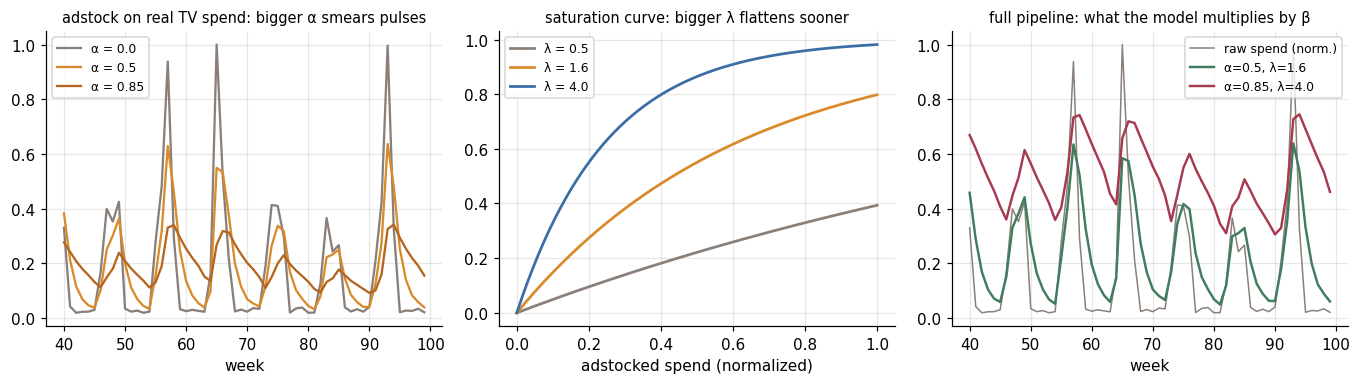

✓ adstock smooths and delays; saturation compresses into [0, 1); β (next section) will set the KPI scale


In [7]:
ch = "TV"
x = sc.spend[ch].to_numpy(float)
xn = x / x.max()                      # the model works on max-normalized spend
win = slice(40, 100)                  # a 60-week window, enough to see pulses
t = np.arange(len(xn))[win]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for a, colr in zip((0.0, 0.5, 0.85), (MUTED, AMBER, ACCENT)):
    axes[0].plot(t, dgp._geom_adstock(xn, a)[win], color=colr, lw=1.5,
                 label=f"α = {a}")
axes[0].set_title(f"adstock on real {ch} spend: bigger α smears pulses",
                  fontsize=9.5)
axes[0].set_xlabel("week"); axes[0].legend(fontsize=8)

xg = np.linspace(0, 1, 200)
for lam, colr in zip((0.5, 1.6, 4.0), (MUTED, AMBER, SKY)):
    axes[1].plot(xg, dgp._logistic_sat(xg, lam), color=colr, lw=1.8,
                 label=f"λ = {lam}")
axes[1].set_title("saturation curve: bigger λ flattens sooner", fontsize=9.5)
axes[1].set_xlabel("adstocked spend (normalized)"); axes[1].legend(fontsize=8)

axes[2].plot(t, xn[win], color=MUTED, lw=1.0, label="raw spend (norm.)")
for (a, lam), colr in zip(((0.5, 1.6), (0.85, 4.0)), (LEAF, BERRY)):
    y_tr = dgp._logistic_sat(dgp._geom_adstock(xn, a), lam)
    axes[2].plot(t, y_tr[win], color=colr, lw=1.6, label=f"α={a}, λ={lam}")
axes[2].set_title("full pipeline: what the model multiplies by β", fontsize=9.5)
axes[2].set_xlabel("week"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# CLAIM: higher α visibly smooths (smaller week-to-week jumps); saturation
# output lives in [0, 1); the pipeline preserves the pulse timing.
rough = lambda a: float(np.std(np.diff(dgp._geom_adstock(xn, a))))
assert rough(0.85) < rough(0.5) < rough(0.0), "adstock should smooth the series"
full = dgp._logistic_sat(dgp._geom_adstock(xn, 0.5), 1.6)
assert full.min() >= 0 and full.max() < 1
print("✓ adstock smooths and delays; saturation compresses into [0, 1); "
      "β (next section) will set the KPI scale")

### 🎛️ Live exploration (run me!)

Drag the sliders. Watch two things at once: **left**, the transformed series
the model would actually multiply by β; **right**, the response curve with the
real spend-weeks scattered along it, so you can see *where on the curve this
channel actually lives*. Try:

- α → 0.9 on Search: a fast-twitch channel suddenly behaves like brand TV.
- λ → 4 on TV: most weeks pile onto the flat part — extra spend buys nothing.
- λ → 0.3: the curve is straight in the observed range; saturation
  effectively off.

The model does not know α and λ. It puts priors on both, *per channel*, and
learns them from the data — these sliders are your hands on knobs that NUTS
(workshop 02) will soon turn by posterior inference.

interactive(children=(Dropdown(description='channel', options=('TV', 'Search', 'Social', 'Display'), value='TV…

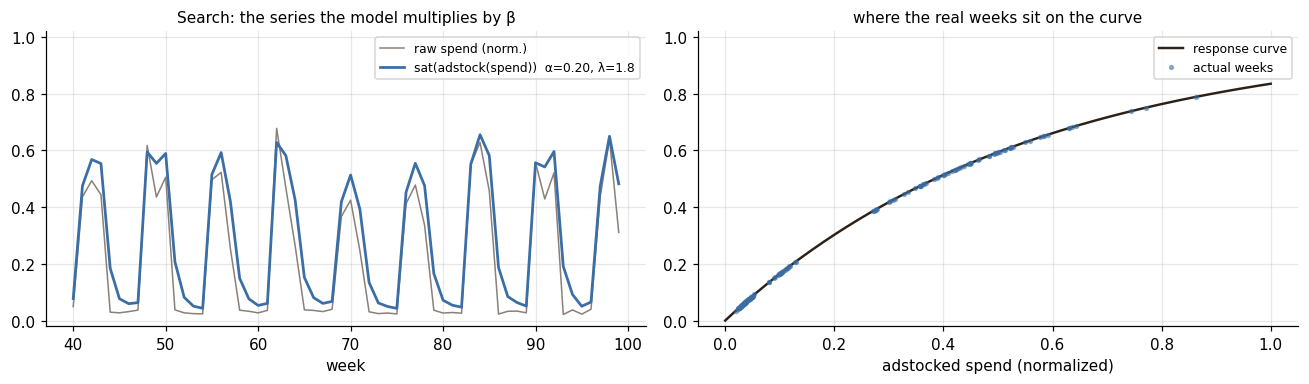

✓ transform explorer live — drag the sliders above


In [8]:
from ipywidgets import interact, FloatSlider, Dropdown

def explore_transform(channel="TV", alpha=0.6, lam=1.6):
    "Push a channel's real spend through adstock(alpha) then saturation(lam)."
    xs = sc.spend[channel].to_numpy(float)
    xsn = xs / xs.max()
    ad = dgp._geom_adstock(xsn, alpha)
    tr = dgp._logistic_sat(ad, lam)
    figw, axw = plt.subplots(1, 2, figsize=(12, 3.6))
    tt = np.arange(len(xsn))[win]
    axw[0].plot(tt, xsn[win], color=MUTED, lw=1.0, label="raw spend (norm.)")
    axw[0].plot(tt, tr[win], color=PAL[channel], lw=1.8,
                label=f"sat(adstock(spend))  α={alpha:.2f}, λ={lam:.1f}")
    axw[0].set_title(f"{channel}: the series the model multiplies by β", fontsize=10)
    axw[0].set_xlabel("week"); axw[0].set_ylim(-0.02, 1.02); axw[0].legend(fontsize=8)
    grid = np.linspace(0, 1, 200)
    axw[1].plot(grid, dgp._logistic_sat(grid, lam), color=INK, lw=1.6,
                label="response curve")
    axw[1].plot(ad, tr, ".", color=PAL[channel], ms=5, alpha=0.5,
                label="actual weeks")
    axw[1].set_title("where the real weeks sit on the curve", fontsize=10)
    axw[1].set_xlabel("adstocked spend (normalized)")
    axw[1].set_ylim(-0.02, 1.02); axw[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return tr

interact(explore_transform,
         channel=Dropdown(options=sc.channels, value="TV", description="channel"),
         alpha=FloatSlider(min=0.0, max=0.95, step=0.05, value=0.6, description="adstock α"),
         lam=FloatSlider(min=0.3, max=5.0, step=0.1, value=1.6, description="saturation λ"));

# CLAIM: the explorer runs headless and its output is a valid transformed series.
_tr = explore_transform("Search", 0.2, 1.8)
assert _tr.shape == (156,) and _tr.min() >= 0 and _tr.max() < 1
print("✓ transform explorer live — drag the sliders above")

## 4 — Configure the model: writing down your generative story

A model **configuration** is not bureaucracy — it is the diagram from section 1
written as code, plus the priors from workshop 01. Choice by choice:

| choice | what it means | why this value here |
|---|---|---|
| `inference_method = BAYESIAN_NUMPYRO` | run NUTS (workshop 02) on the **numpyro** backend — a fast, JAX-based implementation of the same sampler | quick and reliable on laptops (and sidesteps a macOS multiprocessing quirk in the default backend) |
| `n_draws=500, n_tune=500` | 500 warm-up steps the sampler discards while adapting, then 500 kept draws | workshop speed; production runs use 2000+ of each |
| `n_chains=2` | two independent chains so R-hat can compare them | workshop speed; production uses 4 |
| `use_parametric_adstock=True` | estimate adstock α inside the model (a prior + posterior per channel) instead of fixing it by hand | we want the model to *learn* the carryover you just explored |
| `optim_seed=0` / `random_seed=0` | fix randomness | so your numbers match this notebook's |
| `TrendConfig(type=LINEAR)` | the baseline includes a straight-line drift | matches the gentle drift you saw in section 2 |

What about all the priors — β, α, λ, seasonality, noise? **The framework ships
weakly-informative defaults** for every one of them: priors wide enough not to
bully the data but tight enough to keep the sampler in sane territory (e.g.,
effect sizes are constrained positive — "ads don't destroy sales" is itself a
prior!). Workshop 01's job was to make you able to *read* such defaults, not to
re-derive them every time. You can override any of them per channel; today we
take the defaults.

In [9]:
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

# Importing pymc installs its own log handler; re-quiet and stop propagation.
for _n in ("pymc", "pymc.sampling", "pymc.stats.convergence",
           "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.CRITICAL); _lg.propagate = False

cfg = ModelConfig(
    inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
    n_draws=500, n_tune=500, n_chains=2,
    use_parametric_adstock=True, optim_seed=0,
)
mmm = BayesianMMM(panel, cfg, TrendConfig(type=TrendType.LINEAR))
print("model built:", mmm.n_channels, "channels |", mmm.n_controls,
      "control |", len(mmm.y), "weeks")
print("free parameters get priors+posteriors: β per channel, adstock α per "
      "channel, saturation λ per channel, intercept, trend slope, seasonality, "
      "control coefficients, noise σ")

# CLAIM: the configuration encodes the workshop-speed sampling plan and the
# learn-the-transforms choice.
assert cfg.n_draws == 500 and cfg.n_tune == 500 and cfg.n_chains == 2
assert cfg.use_parametric_adstock is True
assert mmm.n_channels == 4 and mmm.n_controls == 1
print("✓ generative story written down — ready to sample")

model built: 4 channels | 1 control | 156 weeks
free parameters get priors+posteriors: β per channel, adstock α per channel, saturation λ per channel, intercept, trend slope, seasonality, control coefficients, noise σ
✓ generative story written down — ready to sample


## 5 — Fit, then face the gate

One call runs the whole workshop-02 machine: NUTS explores the joint posterior
over *all* the parameters at once — every β, every α, every λ, the trend, the
seasonality, the noise. On a laptop this world takes around a minute.

Then — before reading **any** result — the diagnostics gate from workshop 02:

1. **R-hat** ≈ 1.00 (chains agree with each other),
2. **divergences** = 0 (the sampler never broke),
3. **bulk ESS** comfortably in the hundreds (enough effective draws to trust
   summaries).

In [10]:
t0 = time.perf_counter()
with quiet():
    fit = mmm.fit(random_seed=0)
elapsed = time.perf_counter() - t0

diag = {
    "r-hat max": round(fit.diagnostics["rhat_max"], 3),
    "divergences": int(fit.diagnostics["divergences"]),
    "min bulk ESS": round(fit.diagnostics["ess_bulk_min"]),
}
print(f"sampled in {elapsed:.0f}s")
display(pd.Series(diag, name="diagnostics gate").to_frame())

# CLAIM: the gate is green (directional thresholds from workshop 02; seeded).
assert fit.diagnostics["rhat_max"] < 1.05, "chains disagree — do not proceed"
assert fit.diagnostics["divergences"] == 0, "sampler broke — do not proceed"
assert fit.diagnostics["ess_bulk_min"] > 100, "too few effective draws"
print("✓ gate passed: chains agree, zero divergences, healthy ESS — "
      "we may now read the posterior")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

sampled in 8s


,diagnostics gate
r-hat max,1.011
divergences,0.000
min bulk ESS,432.000


✓ gate passed: chains agree, zero divergences, healthy ESS — we may now read the posterior


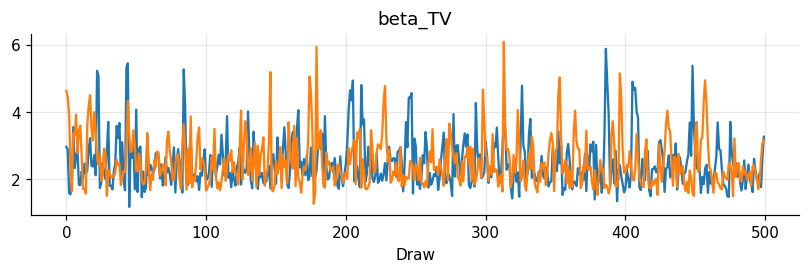

✓ beta_TV trace: overlapping chains, no trends, no stuck regions


In [11]:
import arviz as az

# arviz 1.x plot_trace returns a PlotCollection (not an axes grid) and manages its own
# layout/figsize, so we just render it; the structural checks below assert on the trace itself.
az.plot_trace(fit.trace, var_names=["beta_TV"])
plt.show()

# CLAIM: the trace view exists for the TV effect size and shows 2 chains.
assert fit.trace.posterior["beta_TV"].shape[0] == 2  # chains
assert fit.trace.posterior["beta_TV"].shape[1] == 500  # kept draws
print("✓ beta_TV trace: overlapping chains, no trends, no stuck regions")

Both chains wander the same territory with no trends and no flat stuck
stretches — the "fuzzy caterpillar" from workshop 02. One subtlety worth
naming: passing the gate certifies the **computation** (the sampler faithfully
explored the posterior of *the model we wrote down*). It does **not** certify
that the model is *right*. Keep that distinction warm; it returns in section 6.

## 6 — Does the model reproduce the data?

First sanity check after any fit: push the posterior back through the model and
compare against the observed KPI. Because the posterior is a *distribution*,
the prediction is too — we draw many plausible KPI paths and show the band that
contains 90% of them, not a single line pretending to certainty. Hover to
compare observed vs predicted in any week.

In [12]:
with quiet():
    pred = mmm.predict(return_original_scale=True, hdi_prob=0.9, random_seed=0)

resid = sc.y.to_numpy() - pred.y_pred_mean
r2 = 1 - np.var(resid) / np.var(sc.y.to_numpy())
band_cover = float(((sc.y.to_numpy() >= pred.y_pred_hdi_low)
                    & (sc.y.to_numpy() <= pred.y_pred_hdi_high)).mean())

fig = go.Figure()
fig.add_trace(go.Scatter(x=sc.weeks, y=pred.y_pred_hdi_high, line=dict(width=0),
                         showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter(x=sc.weeks, y=pred.y_pred_hdi_low, line=dict(width=0),
                         fill="tonexty", fillcolor="rgba(59,110,165,0.25)",
                         name="90% predictive band", hoverinfo="skip"))
fig.add_trace(go.Scatter(x=sc.weeks, y=pred.y_pred_mean, name="posterior mean",
                         line=dict(color=SKY, width=1.6),
                         hovertemplate="%{x|%d %b %Y}<br>predicted %{y:.0f}<extra></extra>"))
fig.add_trace(go.Scatter(x=sc.weeks, y=sc.y, name="observed", mode="markers",
                         marker=dict(color=INK, size=4, opacity=0.7),
                         hovertemplate="%{x|%d %b %Y}<br>observed %{y:.0f}<extra></extra>"))
fig.update_layout(height=420, title=f"Predicted vs observed — R² = {r2:.2f}, "
                  f"band covers {band_cover:.0%} of weeks",
                  hovermode="x unified", legend=dict(orientation="h", y=1.1),
                  **PLOTLY_LAYOUT)
fig.show()

# CLAIM: strong in-sample fit AND an honest band — ~90% of weeks inside a 90%
# band (a band that catches everything would be telling a different lie).
assert r2 > 0.8, f"fit degraded: R² {r2:.2f}"
assert 0.80 <= band_cover <= 1.0, f"band coverage off: {band_cover:.0%}"
print(f"✓ R² = {r2:.2f}; 90% band covers {band_cover:.0%} of weeks — "
      "fit is strong and the uncertainty is calibrated, not decorative")

Output()

✓ R² = 0.90; 90% band covers 93% of weeks — fit is strong and the uncertainty is calibrated, not decorative


A strong fit — and a deliberately incomplete victory. **A good fit does not
prove correct attribution.** The model could track sales beautifully while
crediting the wrong channels: a model that mistakes seasonality for TV, or a
demand-chasing budget for media effectiveness, can fit *better* than the truth.
On real data this failure is invisible — which is precisely why this series
practices on synthetic worlds, and why the stress-test series
([stress_00](stress_00_the_rosy_picture.ipynb)) exists: it manufactures worlds
where every diagnostic is green and the attribution is silently wrong. Here, in
the clean world, we can do what no real analyst can: **open the answer key.**

## 7 — The moment of truth: grading against the answer key

The model's headline output is each channel's **contribution**, computed by the
counterfactual the term promises: predict sales with history as it happened,
re-predict with one channel's spend forced to zero everywhere, and take the
difference. The framework's `compute_counterfactual_contributions` does this
*per posterior draw*, so each contribution arrives with a 90% **HDI** (highest
density interval, workshop 00) instead of a bare number.

The DGP computed the *true* contributions the same way — same question, same
units — so the comparison below is apples to apples. Unsealing the answer key:

In [13]:
with quiet():
    contrib = mmm.compute_counterfactual_contributions(
        compute_uncertainty=True, hdi_prob=0.9, random_seed=0)

rows = []
for c in sc.channels:
    t = float(sc.true_contribution[c])
    e = float(contrib.total_contributions[c])
    lo = float(contrib.contribution_hdi_low[c])
    hi = float(contrib.contribution_hdi_high[c])
    rows.append({"channel": c, "true": round(t), "estimate": round(e),
                 "hdi 5%": round(lo), "hdi 95%": round(hi),
                 "rel_err": (e - t) / abs(t), "truth in 90% HDI": lo <= t <= hi})
grade = pd.DataFrame(rows).set_index("channel")

show = grade.copy()
show["rel_err"] = show["rel_err"].map("{:+.0%}".format)
display(show)
med_err = grade["rel_err"].abs().median()
coverage = grade["truth in 90% HDI"].mean()
print(f"median |relative error| = {med_err:.0%}   "
      f"truth inside 90% HDI: {coverage:.0%} of channels")

# CLAIM: on a world satisfying its assumptions, the model recovers the causal
# truth — small errors, honest intervals (directional + seeded; probe measured
# ~7% median error with 4/4 coverage at this seed).
assert med_err < 0.25, f"recovery degraded: median |err| {med_err:.0%}"
assert coverage >= 0.75, f"HDI coverage collapsed: {coverage:.0%}"
print("✓ graded: estimates land near truth and the intervals own up to the rest")

Output()

Output()

Output()

Output()

Output()

,true,estimate,hdi 5%,hdi 95%,rel_err,truth in 90% HDI
channel,,,,,,
TV,5668,5261,4214,6505,-7%,True
Search,4531,4201,3462,5037,-7%,True
Social,4017,4166,3585,4812,+4%,True
Display,2958,2789,2108,3635,-6%,True


median |relative error| = 6%   truth inside 90% HDI: 100% of channels
✓ graded: estimates land near truth and the intervals own up to the rest


In [14]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=list(grade.index), y=grade["true"], name="causal truth (answer key)",
    marker_color=INK, opacity=0.85,
    hovertemplate="%{x} truth: %{y:.0f}<extra></extra>"))
fig.add_trace(go.Bar(
    x=list(grade.index), y=grade["estimate"], name="model estimate (90% HDI)",
    marker_color=[PAL[c] for c in grade.index],
    error_y=dict(type="data", symmetric=False,
                 array=(grade["hdi 95%"] - grade["estimate"]).clip(lower=0),
                 arrayminus=(grade["estimate"] - grade["hdi 5%"]).clip(lower=0),
                 color=INK, thickness=1.5),
    hovertemplate="%{x} estimate: %{y:.0f}<extra></extra>"))
fig.update_layout(barmode="group", height=420,
                  title="Truth vs estimate, per channel — whiskers are the 90% HDI",
                  yaxis_title="total contribution (KPI units)",
                  legend=dict(orientation="h", y=1.1), **PLOTLY_LAYOUT)
fig.show()

# CLAIM: the chart shows both bar families and the model also recovers the
# channel RANKING (which channel matters most), not just the levels.
assert len(fig.data) == 2
true_rank = list(grade["true"].sort_values(ascending=False).index)
est_rank = list(grade["estimate"].sort_values(ascending=False).index)
assert true_rank[0] == est_rank[0], "top channel mis-ranked"
print(f"✓ top channel correctly identified: {est_rank[0]} "
      f"(true ranking {' > '.join(true_rank)})")

✓ top channel correctly identified: TV (true ranking TV > Search > Social > Display)


Read the table and the chart together, the way you would brief a stakeholder:

- Every **estimate** lands close to its truth bar, and the live `rel_err`
  column quantifies "close" per channel — no eyeballing required.
- Every **whisker** (the 90% HDI) brackets the truth. This is the part a
  point-estimate model cannot give you: the interval *claims* a range, and in a
  world where we can check, the claim holds.
- The **ranking** — which channel contributes most — comes out right, which is
  what budget decisions actually consume.

This is what *earned trust* looks like: not "the model converged," but "on a
world where the answer is checkable, the model finds it, and its stated
uncertainty is honest." The stress series then asks the harder question — what
happens when the world stops cooperating?

## 8 — What just happened, in Bayes terms

Strip away the marketing words and you have run exactly the workflow of
workshops 00–02, at scale:

1. **A generative story** (section 1's diagram) with a few dozen unknown
   parameters: four βs, four adstock αs, four saturation λs, intercept, trend
   slope, seasonality coefficients, a price coefficient, noise σ.
2. **Priors** on all of them (the framework's weakly-informative defaults —
   workshop 01).
3. **The likelihood** of 156 observed weeks under any candidate parameter
   setting.
4. **NUTS** (workshop 02) exploring the joint posterior — every kept draw is a
   *complete parameter set*: a full candidate explanation of three years of
   business history.

The contributions you just graded were never parameters at all. They are
**derived quantities**: for *each posterior draw*, the model runs its
zero-out counterfactual and gets one complete attribution story; the table in
section 7 summarizes a thousand such stories. The plot below makes that
concrete — each thin line is one draw's week-by-week claim about what TV
contributed. The posterior is not a number with error bars bolted on; it is a
*population of full explanations*, and every summary we report is a statistic
of that population.

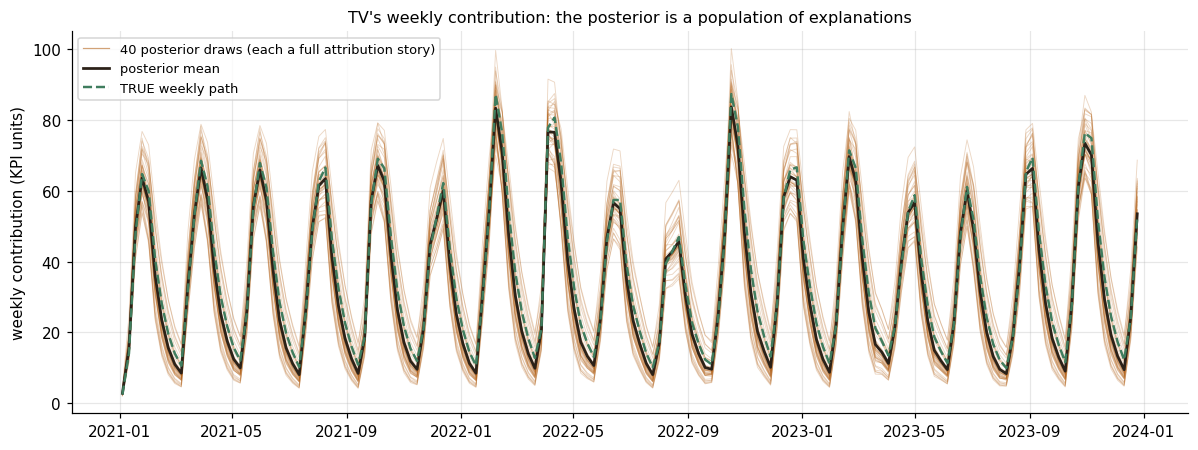

✓ 1000 draws × 156 weeks of TV stories; their totals ARE section 7's estimate — contributions are statistics of draws


In [15]:
post = fit.trace.posterior
cc = post["channel_contributions"]          # dims: (chain, draw, obs, channel)
flat = cc.values.reshape(-1, cc.shape[2], cc.shape[3]) * mmm.y_std  # -> KPI units

ci = sc.channels.index("TV")
xn_tv = sc.spend["TV"].to_numpy(float) / float(sc.spend["TV"].max())
true_path = dgp._AMP["TV"] * dgp._logistic_sat(
    dgp._geom_adstock(xn_tv, dgp._ALPHA["TV"]), dgp._LAM["TV"])

rng = np.random.default_rng(0)
picks = rng.choice(flat.shape[0], size=40, replace=False)
fig, ax = plt.subplots(figsize=(11, 4.2))
for k in picks:
    ax.plot(sc.weeks, flat[k, :, ci], color=ACCENT, lw=0.6, alpha=0.25)
ax.plot([], [], color=ACCENT, lw=0.8, alpha=0.6,
        label="40 posterior draws (each a full attribution story)")
ax.plot(sc.weeks, flat[:, :, ci].mean(axis=0), color=INK, lw=1.8,
        label="posterior mean")
ax.plot(sc.weeks, true_path, color=LEAF, lw=1.6, ls="--", label="TRUE weekly path")
ax.set_title("TV's weekly contribution: the posterior is a population of "
             "explanations", fontsize=10.5)
ax.set_ylabel("weekly contribution (KPI units)"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

# CLAIM 1: the derived-quantity bookkeeping is exact — per-draw totals average
# to the counterfactual estimate we graded in section 7 (same draws, same scale).
per_draw_totals = flat[:, :, ci].sum(axis=1)
assert flat.shape == (1000, 156, 4)
assert abs(per_draw_totals.mean() - grade.loc["TV", "estimate"]) \
    / grade.loc["TV", "estimate"] < 0.02
# CLAIM 2: the true weekly path integrates to the answer key's TV total.
assert abs(true_path.sum() - float(sc.true_contribution["TV"])) < 1e-6
print(f"✓ {flat.shape[0]} draws × {flat.shape[1]} weeks of TV stories; their "
      "totals ARE section 7's estimate — contributions are statistics of draws")

### 🎛️ Live exploration (run me!) — tour the posterior by channel

One last toy before the wrap-up: pick a channel and see the posterior for its
three personal parameters — effect size β, adstock α, saturation λ. For α and λ
the dashed line marks the **true** value the world was generated with (β lives
on the model's internal standardized scale, so it has no directly comparable
truth line).

Notice as you flip channels that some parameters are pinned down sharply while
others stay wide *in the same healthy fit* — often because β and λ can partly
trade off against each other (a taller curve bent sooner can mimic a shorter
curve bent later). The *contribution* you graded in section 7 stays
well-determined even when the individual knobs share credit. Reading these
shapes properly — widths, trade-offs, what the data did and didn't pin down —
is exactly [workshop 04](workshop_04_reading_the_posterior.ipynb)'s job.

interactive(children=(Dropdown(description='channel', options=('TV', 'Search', 'Social', 'Display'), value='TV…

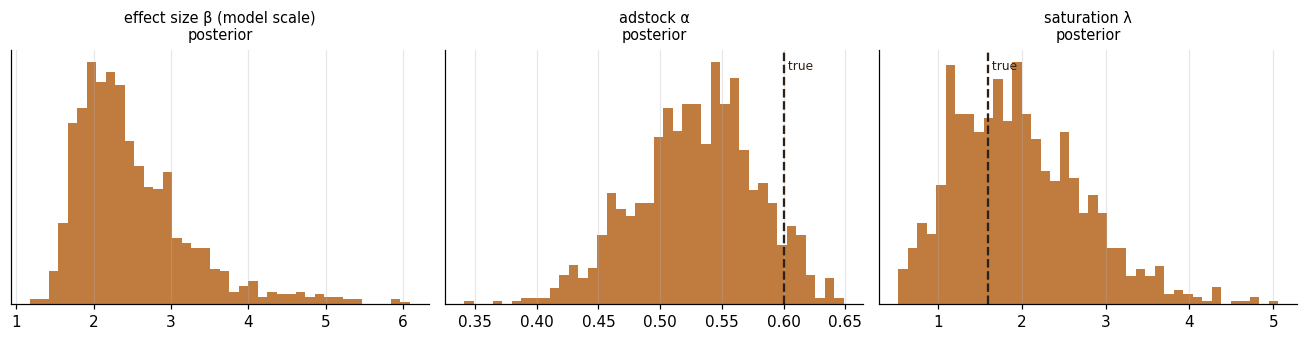

✓ posterior explorer live — flip channels and compare how sharply each parameter was learned


In [16]:
TRUE_PARAM = {"adstock α": dgp._ALPHA, "saturation λ": dgp._LAM}

def explore_posterior(channel="TV"):
    "Posterior histograms for one channel's beta / adstock alpha / saturation lam."
    names = [(f"beta_{channel}", "effect size β (model scale)"),
             (f"adstock_alpha_{channel}", "adstock α"),
             (f"sat_lam_{channel}", "saturation λ")]
    figw, axw = plt.subplots(1, 3, figsize=(12, 3.2))
    for axi, (var, label) in zip(axw, names):
        draws = post[var].values.ravel()
        axi.hist(draws, bins=40, color=PAL[channel], alpha=0.85)
        axi.set_title(f"{label}\nposterior", fontsize=9.5)
        if label in ("adstock α", "saturation λ"):
            tv = TRUE_PARAM[label][channel]
            axi.axvline(tv, color=INK, ls="--", lw=1.5)
            axi.text(tv, axi.get_ylim()[1] * 0.92, " true", fontsize=8, color=INK)
        axi.set_yticks([])
    plt.tight_layout(); plt.show()

interact(explore_posterior,
         channel=Dropdown(options=sc.channels, value="TV", description="channel"));

# CLAIM: every channel exposes the three personal posteriors the explorer reads.
for c in sc.channels:
    for v in (f"beta_{c}", f"adstock_alpha_{c}", f"sat_lam_{c}"):
        assert v in post.data_vars, f"missing posterior var {v}"
explore_posterior("TV")
print("✓ posterior explorer live — flip channels and compare how sharply "
      "each parameter was learned")

## 9 — What to remember, and where this goes

**The glossary, now with scars** — you have touched every one of these:

| term | where you met it |
|---|---|
| **MMM / KPI / channel** | section 2 — three years of weekly Sales and four spend lines |
| **MFF** | section 2 — the long, one-row-per-variable×period input format |
| **adstock / saturation** | section 3 — sliders on real TV spend; section 8 — their posteriors vs truth |
| **baseline** | sections 1 & 4 — intercept + trend + seasonality + price |
| **contribution** | section 7 — the zero-out counterfactual, graded against the answer key |
| **ROAS** | section 1's table — contribution ÷ spend; it becomes a *distribution* in workshop 05 |
| **HDI** | section 7 — the whiskers whose claim we could actually check |

**The three takeaways:**

1. **An MMM is the Bayesian workflow wearing a marketing costume.** Generative
   story → priors → likelihood → NUTS → posterior. Nothing new was needed
   beyond workshops 00–02; the diagram just gave the parameters business names.
2. **Contributions are derived quantities, not parameters.** Each posterior
   draw implies a complete attribution story; the reported numbers and HDIs are
   statistics over that population of stories. This idea powers everything in
   workshop 05.
3. **Train where the truth is checkable.** Green diagnostics + a beautiful fit
   certify the *computation*, not the *attribution*. We earned trust here by
   grading against an answer key — and real data never has one.

**Next in the series:**

- [workshop_04_reading_the_posterior.ipynb](workshop_04_reading_the_posterior.ipynb)
  — this fit's posterior under a magnifying glass: draws, HDIs, forest plots,
  what the data learned vs what the prior asserted, posterior-predictive checks.
- [workshop_05_from_draws_to_decisions.ipynb](workshop_05_from_draws_to_decisions.ipynb)
  — from draws to money: ROAS distributions, "what should I cut?" as a
  probability statement, decision-making per draw.

**After the workshop, two field trips:**
[00_overview.ipynb](00_overview.ipynb) tells a full modeling engagement as a
story (the Aurora notebooks), and
[stress_00_the_rosy_picture.ipynb](stress_00_the_rosy_picture.ipynb) shows the
dark twin of today's happy ending — worlds where every gate is green and the
attribution is silently wrong, and what it takes to catch them.